# Reproduce — González-Palacio et al. (2023), IEEE IoT-J

**Run All** does the whole project: the pipeline (~10 min), the tests, then every table and figure. Inputs: `data/LoRaWAN_PathLossMeasurements.csv` and `paper_digitized/` (the paper's curves, for the hollow markers). Outputs land in `tables/`, `figures/`, `models/`. To only redraw from existing outputs, skip section 1.

## 1. Run the pipeline

data → conventional models → CPLS models (MLR, ANN, SVR, RF) → residuals → ADR and energy → headline claims. Every choice the paper leaves open is in `run_final.CONFIG`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd() / 'src'))
import run_final
print({k: run_final.CONFIG[k] for k in ('algorithm1_variant', 'delivery_rule', 'sf_max', 'restore_frac_rssi_only', 'restore_frac_coupled')})
run_final.main()

{'algorithm1_variant': 'text', 'delivery_rule': 'residual', 'sf_max': 12, 'restore_frac_rssi_only': 0.0025, 'restore_frac_coupled': 0.0015}
[10:41:18] 1/6 data
[10:41:19] 2/6 conventional models
[10:41:22] 3/6 CPLS models
[10:41:23]   MLR: test RMSE 1.9352  R2 0.9100  cv 1.9445+/-0.0026  (1s)
[10:43:02]   ANN: test RMSE 1.5365  R2 0.9437  cv 1.5861+/-0.0140  (99s)
[10:46:43]   SVR: test RMSE 1.5730  R2 0.9407  cv 1.5981+/-0.0148  (221s)
[10:48:04]   RF: test RMSE 1.5254  R2 0.9441  cv 1.5430+/-0.0034  (82s)
[10:48:04] 4/6 residuals
[10:48:10]   residuals: nu 11.09 (paper 11.43), kurt +3.72, range -18.0..19.0; Appendix psi scale 1.740 dB
[10:48:10] 5/6 ADR / energy
[10:49:05]   ADR LM@99 10.85 | ANN 3.85 | energy ANN/SVR/RF 45.5/49.2/46.8
[10:49:05] 6/6 claims
[10:49:06] done -> tables/, figures/, models/


## 2. Tests

Algorithm 1 vectorised == scalar transcription (5 tests); CONFIG forwarding, cache invalidation, delivery-rule dependence (3).

In [2]:
import subprocess
for t in ('tests/test_adr_equivalence.py', 'tests/test_pipeline_behaviour.py'):
    r = subprocess.run([sys.executable, t], capture_output=True, text=True)
    print(t, '->', 'OK' if r.returncode == 0 else 'FAILED'); print(r.stdout.strip()[-600:] if r.returncode == 0 else r.stderr[-1500:])

tests/test_adr_equivalence.py -> OK
scalar == vectorised: OK
as-printed degeneracy confirmed: OK
SF bounds: OK
line-28 unbounded-TP defect confirmed: OK
text variant: TP from the margin at the final SF, never above max_tp: OK
tests/test_pipeline_behaviour.py -> OK
CONFIG forwarding: OK
cache invalidation: OK
delivery-rule dependence: OK


## 3. Tables and figures

Everything below is read from `tables/*.csv`; figures are drawn by `src/plots.py`.

In [3]:
import json
import pandas as pd, matplotlib.pyplot as plt
import plots
F = pathlib.Path.cwd() / 'tables'
pd.set_option('display.width', 200, 'display.max_columns', 30, 'display.precision', 3)

## Headline claims — what each verdict rests on

In [4]:
pd.read_csv(F / 'headline_claims.csv')

,claim,paper,ours,verdict,basis
0,"RMSE up to 1.566 dB, R2 up to 0.94",1.566 / 0.94,1.525 / 0.9441,REPRODUCED,reconstructed data (calibrated to the paper's ...
1,Model ranking by test RMSE,RF < ANN < SVR < MLR,RF < ANN < SVR < MLR,REPRODUCED,not a calibration target
2,Best ML model: PDR > 99 % at LM = 4 dB,4 dB,3.85 dB,REPRODUCED,"not a calibration target (residual rule, packe..."
3,Conventional ADR needs LM = 11 dB for 99 %,11 dB,10.85 dB,REPRODUCED,reconstructed data (the coupled fraction is ca...
4,Energy saving up to 43 % vs conventional ADR (...,43.5 % (ANN); max 43.5 %,45.5 % (ANN); max 49.2 % (SVR),REPRODUCED,not a calibration target; under the paper's SF...
5,"Shadow fading is Student-t, nu = 11.43",11.43,11.09,CALIBRATED,calibration target of D1


## Fig. 4 — conventional models

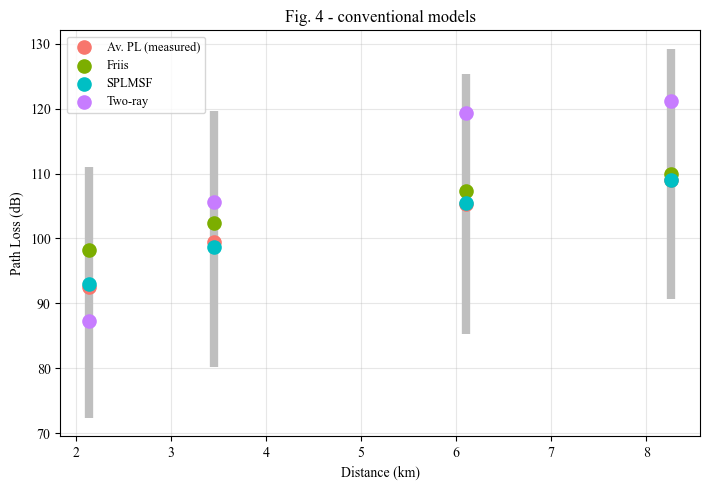

In [5]:
plots.fig04(F); plt.show()

In [6]:
pd.read_csv(F / 'table_iii_conventional.csv')

,model,train_rmse,test_rmse,test_r2,paper_test_rmse,paper_test_r2,rmse_err_pct
0,Friis,4.072,4.055,0.843,4.002,0.825,1.327
1,Two-ray,11.214,11.212,0.813,10.981,0.805,2.107
2,Okumura-Hata,45.932,45.925,0.815,39.712,0.806,15.647
3,SPLMSF,2.567,2.555,0.843,2.660,0.824,-3.963


## Table IV — CPLS models

In [7]:
pd.read_csv(F / 'table_iv_cpls.csv')

,model,n_fit_rows,n_cv_rows,cv_rmse,cv_rmse_sd,test_rmse,test_r2,paper_train_rmse,paper_train_s,paper_test_rmse,paper_test_r2,test_rmse_err_pct
0,MLR,741330,741330,1.945,0.003,1.935,0.910,1.951,0.001,1.951,0.905,-0.809
1,ANN,741330,100000,1.586,0.014,1.537,0.944,1.706,0.135,1.613,0.935,-4.742
2,SVR,50000,50000,1.598,0.015,1.573,0.941,2.021,0.428,1.626,0.934,-3.257
3,RF,741330,741330,1.543,0.003,1.525,0.944,1.919,0.339,1.566,0.939,-2.589


## Fig. 11 — PDR vs link margin

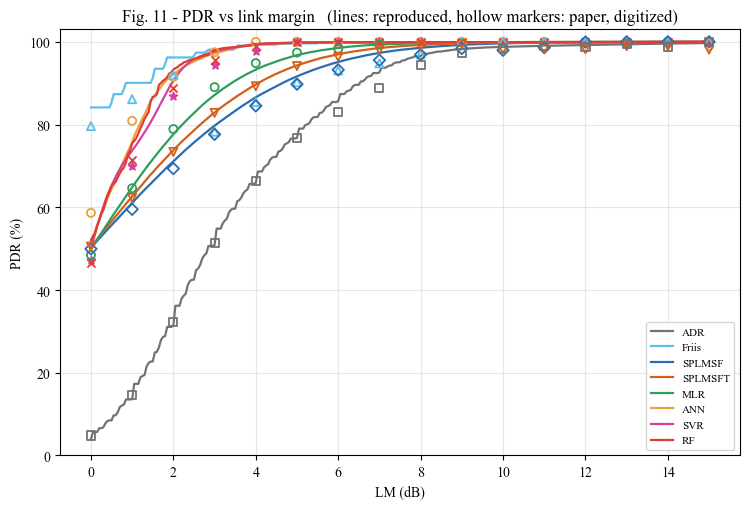

In [8]:
plots.fig11(F); plt.show()

In [9]:
pd.read_csv(F / 'fig11_link_margins.csv').pivot(index='scheme', columns='pdr', values='LM_dB')

pdr,80,85,90,95,99
scheme,,,,,
ADR,5.25,5.85,6.55,7.45,10.85
ANN,1.20,1.45,1.80,2.45,3.85
Friis,0.00,0.50,0.85,1.85,3.55
MLR,2.25,2.75,3.45,4.45,6.50
RF,1.25,1.45,1.70,2.30,3.70
SPLMSF,3.05,3.80,4.65,6.00,8.60
SPLMSFT,2.70,3.30,4.10,5.25,7.60
SVR,1.45,1.70,2.00,2.40,3.75


## Figs. 12–13 — at the paper's operating LMs (figure reconstruction; achieved PDRs differ from the labels)

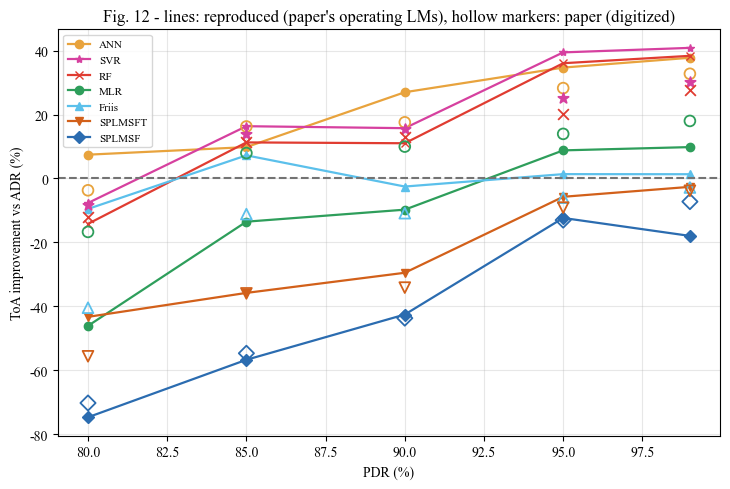

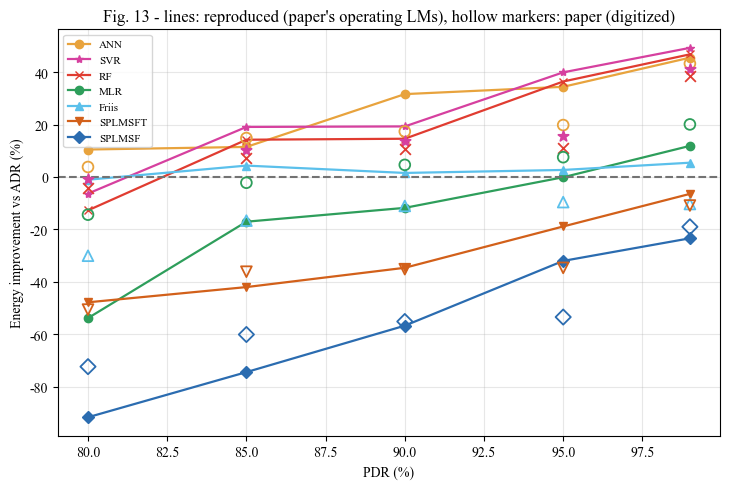

In [10]:
plots.fig12(F); plots.fig13(F); plt.show()

In [11]:
e = pd.read_csv(F / 'fig12_13_energy_toa.csv'); e[e.pdr == 99][['scheme', 'LM_dB', 'pdr_at_LM', 'energy_improvement_pct', 'toa_improvement_pct']]

,scheme,LM_dB,pdr_at_LM,energy_improvement_pct,toa_improvement_pct
32,ADR,11.0,99.027,0.000,0.000
33,Friis,5.0,99.603,5.446,1.336
34,SPLMSF,12.0,99.883,-23.379,-17.942
35,SPLMSFT,9.0,99.620,-6.444,-2.608
36,MLR,7.0,99.340,11.863,9.815
37,ANN,4.0,99.212,45.503,37.726
38,SVR,4.0,99.326,49.239,40.826
39,RF,4.0,99.359,46.770,38.339


## Figs. 14–15 — MLR residual QQ plots

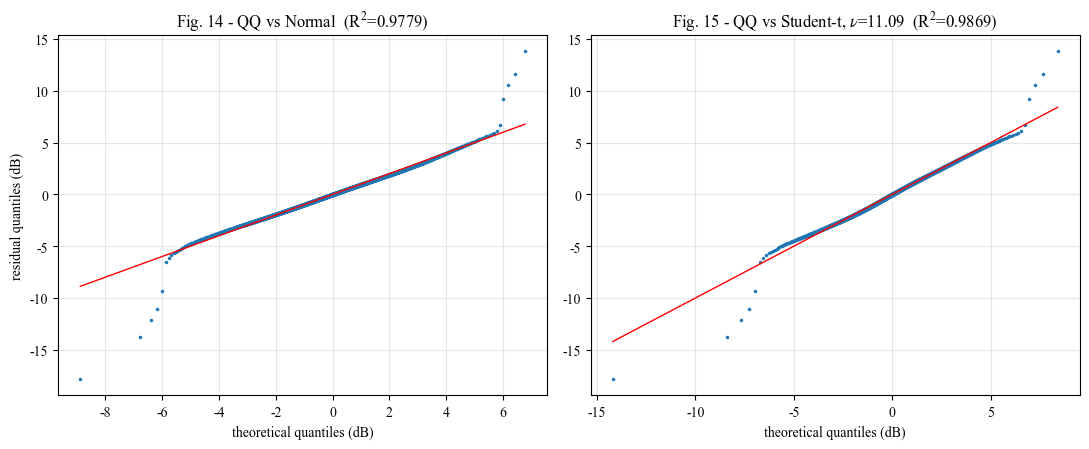

In [12]:
plots.fig14_15(F); plt.show()

In [13]:
pd.read_csv(F / 'appendix_residual_tests.csv')

,test,statistic,pvalue,paper
0,KS vs fitted normal,0.013784282064620346,8.804e-123,p = 2.2e-16
1,Durbin-Watson (split order),1.9976173895917237,NaN,1.67
2,Durbin-Watson (device+time order),1.1532108149004279,NaN,not run
3,Breusch-Pagan,3600.284875210669,0.000e+00,p = 1e-16
4,excess kurtosis,3.7178737392379526,NaN,fat tails
5,Student-t nu (MLE),11.087079512214792,NaN,11.43
6,"Student-t scale at nu = 11.43 (Appendix psi, dB)",1.7404269282048983,NaN,not reported
7,QQ R2 vs t,0.9869050426575299,NaN,0.996
8,QQ R2 vs normal,0.9779099166975755,NaN,not reported
9,residual range dB,-17.98..18.95,NaN,~ -13..+10 (Fig.14)
